# Cài đặt các thư viện cần thiết cho việc tính toán toán học và dựng đồ họa

In [1]:
!pip install pandas-stubs scikit-image matplotlib seaborn jinja2

In [17]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Cấu hình giao diện đồ thị chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Đường dẫn tài nguyên hệ thống
INPUT_DIR = 'images'
OUTPUT_DIR = 'results'
CSV_MAIN = os.path.join(OUTPUT_DIR, 'csv/complete_benchmark.csv')
CSV_ACCURACY = os.path.join(OUTPUT_DIR, 'csv/o1_accuracy_verification.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

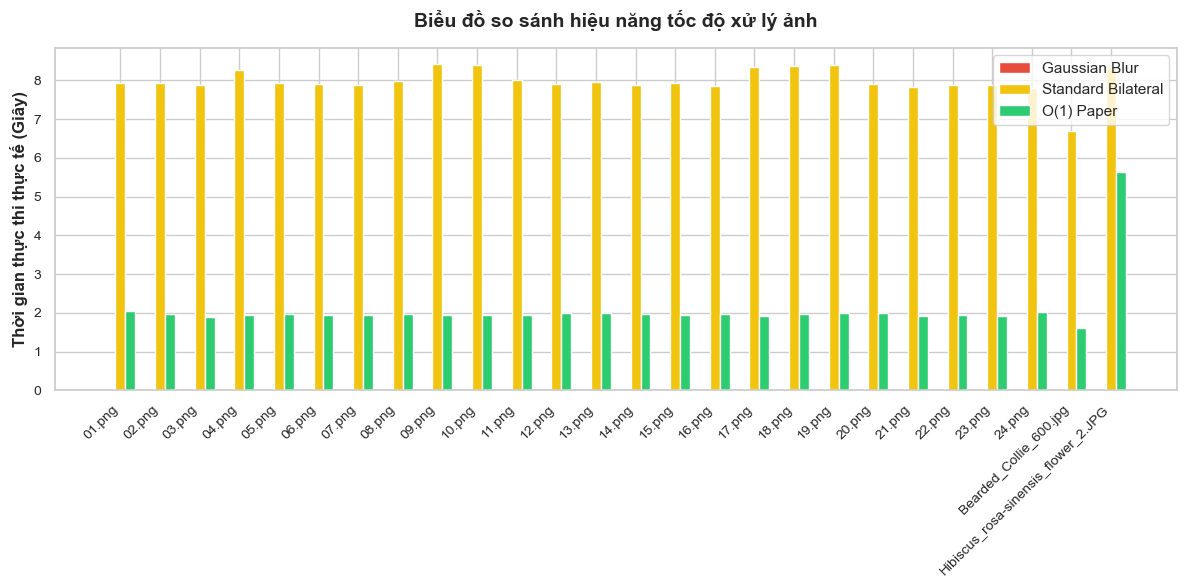

C:\Users\nguye\AppData\Local\Temp\ipykernel_17500\3778130065.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_speed['Image_Name'], rotation=45, ha='right')


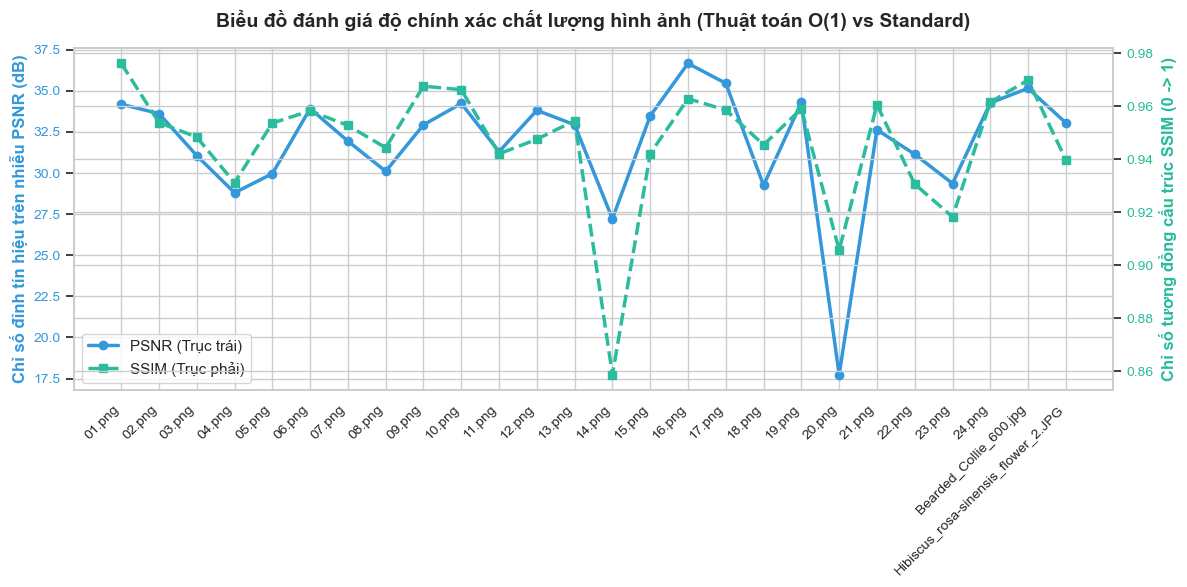

------------------------------------------------------------------------------------------
[XONG] Biểu đồ tốc độ xử lý đã xuất tại : results\charts\speed_comparison_chart.png
[XONG] Biểu đồ độ chính xác đã xuất tại: results\charts\accuracy_metrics_chart.png
------------------------------------------------------------------------------------------


In [21]:
# Cell 2: Đọc file CSV từ mục csv/ và dựng các biểu đồ hiệu năng, độ chính xác vào mục charts/
if os.path.exists(CSV_MAIN):
    df_speed = pd.read_csv(CSV_MAIN)

    # Định nghĩa đường dẫn tới mục charts nằm trong results
    CHART_DIR = os.path.join(OUTPUT_DIR, 'charts')
    os.makedirs(CHART_DIR, exist_ok=True)

    # =========================================================================
    # BIỂU ĐỒ 1: SO SÁNH HIỆU NĂNG TỐC ĐỘ (THỜI GIAN CHẠY)
    # =========================================================================
    plt.figure(figsize=(12, 6))
    x = np.arange(len(df_speed['Image_Name']))
    width = 0.25

    plt.bar(x - width, df_speed['Gaussian_Time (s)'], width, label='Gaussian Blur', color='#e74c3c')
    plt.bar(x, df_speed['Standard_Time (s)'], width, label='Standard Bilateral', color='#f1c40f')
    plt.bar(x + width, df_speed['O1_Paper_Time (s)'], width, label='O(1) Paper', color='#2ecc71')

    plt.ylabel('Thời gian thực thi thực tế (Giây)', fontweight='bold')
    plt.title('Biểu đồ so sánh hiệu năng tốc độ xử lý ảnh', fontweight='bold', pad=15)
    plt.xticks(x, df_speed['Image_Name'], rotation=45, ha='right')
    plt.legend(frameon=True)
    plt.tight_layout()

    # Lưu biểu đồ tốc độ vào mục results/charts/
    speed_chart_path = os.path.join(CHART_DIR, 'speed_comparison_chart.png')
    plt.savefig(speed_chart_path, dpi=300)
    plt.show()
    plt.close()

    # =========================================================================
    # BIỂU ĐỒ 2: ĐÁNH GIÁ ĐỘ CHÍNH XÁC ĐỒ HỌA (PSNR & SSIM SONG SONG)
    # =========================================================================
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Trục Y bên trái: Biểu diễn chỉ số toán học PSNR
    color_psnr = '#3498db'
    ax1.set_ylabel('Chỉ số đỉnh tín hiệu trên nhiễu PSNR (dB)', color=color_psnr, fontweight='bold')
    line1 = ax1.plot(df_speed['Image_Name'], df_speed['O1_vs_Standard_PSNR (dB)'],
                     marker='o', linewidth=2.5, color=color_psnr, label='PSNR (Trục trái)')
    ax1.tick_params(axis='y', labelcolor=color_psnr)
    ax1.set_xticklabels(df_speed['Image_Name'], rotation=45, ha='right')

    # Trục Y bên phải: Biểu diễn chỉ số cấu trúc thị giác SSIM
    ax2 = ax1.twinx()
    color_ssim = '#2abc9c'
    ax2.set_ylabel('Chỉ số tương đồng cấu trúc SSIM (0 -> 1)', color=color_ssim, fontweight='bold')
    line2 = ax2.plot(df_speed['Image_Name'], df_speed['O1_vs_Standard_SSIM'],
                     marker='s', linewidth=2.5, color=color_ssim, linestyle='--', label='SSIM (Trục phải)')
    ax2.tick_params(axis='y', labelcolor=color_ssim)

    # Gộp chung Legend của cả hai đồ thị đường
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower left', frameon=True)

    plt.title('Biểu đồ đánh giá độ chính xác chất lượng hình ảnh (Thuật toán O(1) vs Standard)', fontweight='bold', pad=15)
    plt.tight_layout()

    # Lưu biểu đồ độ chính xác vào mục results/charts/
    accuracy_chart_path = os.path.join(CHART_DIR, 'accuracy_metrics_chart.png')
    plt.savefig(accuracy_chart_path, dpi=300)
    plt.show()
    plt.close()

    print("-" * 90)
    print(f"[XONG] Biểu đồ tốc độ xử lý đã xuất tại : {speed_chart_path}")
    print(f"[XONG] Biểu đồ độ chính xác đã xuất tại: {accuracy_chart_path}")
    print("-" * 90)
else:
    print(f"[CẢNH BÁO] Không tìm thấy file dữ liệu tại đường dẫn cấu hình mới: {CSV_MAIN}")
    print("Hãy đảm bảo bạn đã cập nhật lại đường dẫn lưu file CSV trong file main.py sang mục results/csv/ và chạy lại nó.")

In [11]:
# Cell 3: Trích xuất thuật toán từ file _2 và _3 để kiểm thử sai số toán học (PSNR/SSIM)
from filters.constant_time_bilateral_2 import ConstantTimeBilateral as ConstantTimeBilateralModular
from filters.constant_time_bilateral_3 import ConstantTimeBilateralStrict as ConstantTimeBilateralVectorized

S_S = 35
S_R = 0.08
N_SAMPLES = 20

# Khởi tạo instance từ 2 file logic song song
filter_modular = ConstantTimeBilateralModular(n_samples=N_SAMPLES, sigma_s=S_S, sigma_r=S_R)
filter_vectorized = ConstantTimeBilateralVectorized(n_samples=N_SAMPLES, sigma_s=S_S, sigma_r=S_R)

accuracy_records = []
img_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print("\n" + "-" * 80)
print(f'{"IMAGE NAME":<25} | {"PSNR (VEC vs MOD)":<20} | {"SSIM (VEC vs MOD)":<20}')
print("-" * 80)

for f in img_files:
    img = cv2.imread(os.path.join(INPUT_DIR, f))
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Chạy bản Modular (_2)
    res_mod_rgb = filter_modular.apply(img_rgb)
    res_mod = cv2.cvtColor(res_mod_rgb, cv2.COLOR_RGB2BGR)

    # Chạy bản Vectorized cải tiến (_3)
    res_vec_rgb = filter_vectorized.apply(img_rgb)
    res_vec = cv2.cvtColor(res_vec_rgb, cv2.COLOR_RGB2BGR)

    # Tính toán chỉ số sai lệch đồ họa
    val_psnr = psnr(res_mod, res_vec)
    val_ssim = ssim(res_mod, res_vec, channel_axis=2)

    print(f'{f[:25]:<25} | {val_psnr:<20.2f} | {val_ssim:<20.4f}')

    accuracy_records.append({
        'Image_Name': f,
        'PSNR_Vectorized_vs_Modular (dB)': val_psnr,
        'SSIM_Vectorized_vs_Modular': val_ssim
    })

# Xuất ra file CSV riêng biệt trong thư mục results
df_accuracy = pd.DataFrame(accuracy_records)
df_accuracy.to_csv(CSV_ACCURACY, index=False)
print("-" * 80)
print(f"[XONG] Kết quả xác thực độ chính xác toán học đã lưu tại: {CSV_ACCURACY}")


--------------------------------------------------------------------------------
IMAGE NAME                | PSNR (VEC vs MOD)    | SSIM (VEC vs MOD)   
--------------------------------------------------------------------------------
01.png                    | 34.38                | 0.9669              
02.png                    | 38.71                | 0.9771              
03.png                    | 30.44                | 0.9480              
04.png                    | 35.79                | 0.9588              
05.png                    | 31.35                | 0.9411              
06.png                    | 26.29                | 0.9663              
07.png                    | 32.39                | 0.9433              
08.png                    | 33.41                | 0.9708              
09.png                    | 36.71                | 0.9726              
10.png                    | 35.48                | 0.9716              
11.png                    | 33.11            

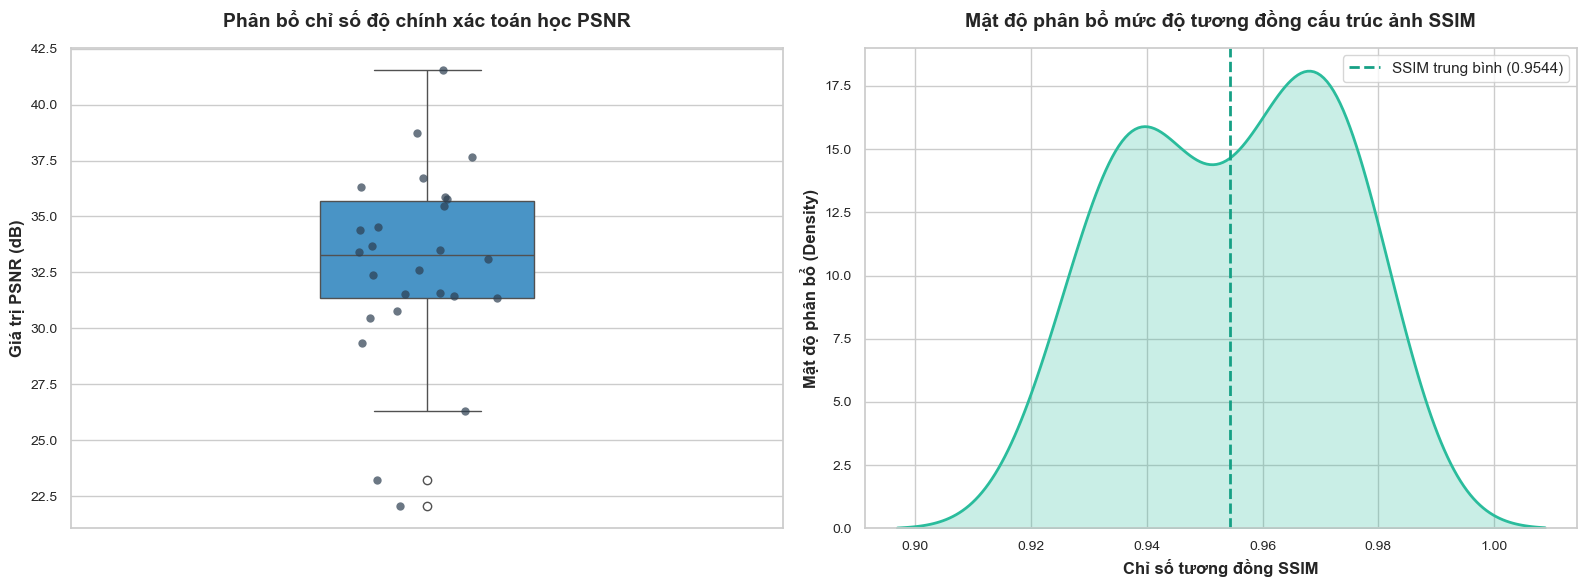

In [12]:
# Cell 4: Vẽ biểu đồ phân bổ chất lượng (Boxplot & Mật độ hạt KDE) để làm báo cáo
if 'df_accuracy' in locals() and not df_accuracy.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Đồ thị Boxplot phân bổ chỉ số nhiễu tín hiệu PSNR
    sns.boxplot(y=df_accuracy['PSNR_Vectorized_vs_Modular (dB)'], ax=ax1, color='#3498db', width=0.3)
    sns.stripplot(y=df_accuracy['PSNR_Vectorized_vs_Modular (dB)'], ax=ax1, color='#2c3e50', size=6, jitter=0.1, alpha=0.7)
    ax1.set_title('Phân bổ chỉ số độ chính xác toán học PSNR', fontweight='bold', pad=15)
    ax1.set_ylabel('Giá trị PSNR (dB)', fontweight='bold')

    # Đồ thị KDE mật độ phân bổ chỉ số tương đồng cấu trúc SSIM
    sns.kdeplot(df_accuracy['SSIM_Vectorized_vs_Modular'], ax=ax2, fill=True, color='#2abc9c', linewidth=2)
    ax2.axvline(df_accuracy['SSIM_Vectorized_vs_Modular'].mean(), color='#16a085', linestyle='--', linewidth=2,
                label=f"SSIM trung bình ({df_accuracy['SSIM_Vectorized_vs_Modular'].mean():.4f})")
    ax2.set_title('Mật độ phân bổ mức độ tương đồng cấu trúc ảnh SSIM', fontweight='bold', pad=15)
    ax2.set_xlabel('Chỉ số tương đồng SSIM', fontweight='bold')
    ax2.set_ylabel('Mật độ phân bổ (Density)', fontweight='bold')
    ax2.legend(frameon=True)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'accuracy_metrics_distribution.png'), dpi=300)
    plt.show()